In [3]:
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [7]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0] #Kaggle dataset
df_ch = pyreadstat.read_sav('/workspaces/malnutrition/Dataset/ch.sav')[0] #GitHub Codespace dataset
# df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0] #Local dataset


# Renaming the columns
features_rename = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = features_rename.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})

# Standardize continuous column
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode nominal categorical column
df3 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy columns to 0/1
cols_to_convert = df3.columns.difference(['child_weight'])
df3[cols_to_convert] = df3[cols_to_convert].astype(int)

df3.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


In [6]:
features_rename.shape

(6749, 14)

In [8]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df3['malnurished'].value_counts())

(6749, 14)
(3581, 12)
(3581, 17)
malnurished
0    1985
1    1596
Name: count, dtype: int64


In [4]:
df3['child_age'].value_counts() # Child age is also categorical, not numerical

child_age
1    1269
2    1260
0    1052
Name: count, dtype: int64

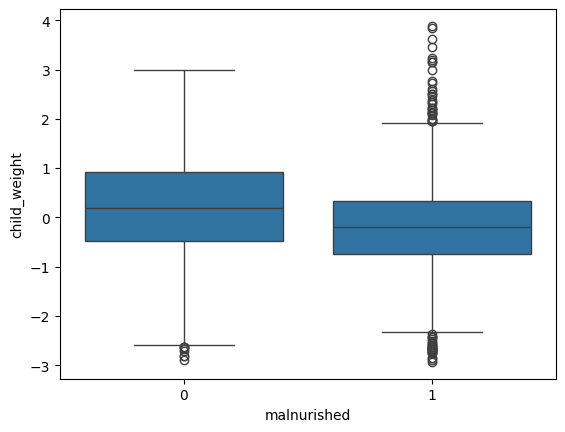

In [5]:
sns.boxplot(x='malnurished', y='child_weight',  data=df3)
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [6]:
# Listing all categorical features
cat_columns = ['child_age', 'ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'province', 'wealth_index']

# Contingency table for categorical features
contingency_tables = {}
for col in cat_columns:
    contingency_tables[col] = pd.crosstab(df2[col], df2['malnurished'])
    print(f"Contingency table for {col}:\n{contingency_tables[col]}\n")

Contingency table for child_age:
malnurished    0    1
child_age            
0.0          657  395
1.0          663  606
2.0          665  595

Contingency table for ever_breastfed:
malnurished        0     1
ever_breastfed            
0.0              142   116
1.0             1843  1480

Contingency table for diarrhoea_last_2_weeks:
malnurished                0     1
diarrhoea_last_2_weeks            
0.0                     1760  1385
1.0                      225   211

Contingency table for fever_last_2_weeks:
malnurished            0     1
fever_last_2_weeks            
0.0                 1515  1232
1.0                  470   364

Contingency table for area:
malnurished     0    1
area                  
0.0           826  787
1.0          1159  809

Contingency table for child_sex:
malnurished     0    1
child_sex             
0.0           978  684
1.0          1007  912

Contingency table for mother_education:
malnurished         0    1
mother_education          
0.0           

In [7]:
from scipy.stats import chi2_contingency

for col in cat_columns:
    contingency_table = contingency_tables[col]
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}:")
    print(f"Chi2: {chi2}, p-value: {p}, degrees of freedom: {dof}\n")

Chi-square test for child_age:
Chi2: 29.795079787417386, p-value: 3.3890707109508297e-07, degrees of freedom: 2

Chi-square test for ever_breastfed:
Chi2: 0.004451594233535216, p-value: 0.9468043983061583, degrees of freedom: 1

Chi-square test for diarrhoea_last_2_weeks:
Chi2: 2.767758691702098, p-value: 0.09618074892964458, degrees of freedom: 1

Chi-square test for fever_last_2_weeks:
Chi2: 0.32814973457000673, p-value: 0.5667506278904322, degrees of freedom: 1

Chi-square test for area:
Chi2: 20.872358977129554, p-value: 4.909279456427756e-06, degrees of freedom: 1

Chi-square test for child_sex:
Chi2: 14.369463371989564, p-value: 0.00015021877433952664, degrees of freedom: 1

Chi-square test for mother_education:
Chi2: 73.96393999831855, p-value: 3.2999851523459003e-15, degrees of freedom: 4

Chi-square test for health_insurance:
Chi2: 15.999267468650553, p-value: 6.336699714470311e-05, degrees of freedom: 1

Chi-square test for province:
Chi2: 126.7661408296377, p-value: 6.161697

### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [8]:
import numpy as np
cramers_v_results = {}

for col in cat_columns:
    if col != 'malnurished':
        table = pd.crosstab(df2[col], df2['malnurished'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        print(f"{col}: Cramér's V = {V:.4f}")

child_age: Cramér's V = 0.0912
ever_breastfed: Cramér's V = 0.0011
diarrhoea_last_2_weeks: Cramér's V = 0.0278
fever_last_2_weeks: Cramér's V = 0.0096
area: Cramér's V = 0.0763
child_sex: Cramér's V = 0.0633
mother_education: Cramér's V = 0.1437
health_insurance: Cramér's V = 0.0668
province: Cramér's V = 0.1881
wealth_index: Cramér's V = 0.1450


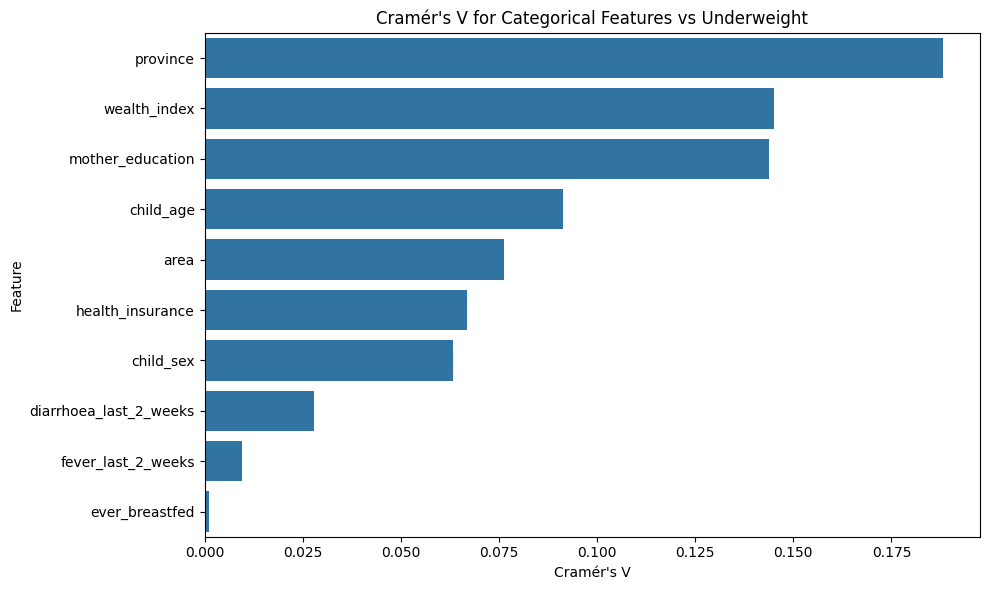

In [9]:
# Cramér's V values
cramers_v_df = pd.DataFrame.from_dict(cramers_v_results, orient='index', columns=['Cramér\'s V'])
cramers_v_df = cramers_v_df.sort_values(by='Cramér\'s V', ascending=False)
cramers_v_df.reset_index(inplace=True)
cramers_v_df.columns = ['Feature', 'Cramér\'s V']
# cramers_v_df.to_csv('/workspaces/malnutrition/MICS/cramers_v_results.csv', index=False)

# Plotting Cramér's V values
plt.figure(figsize=(10, 6))
sns.barplot(x='Cramér\'s V', y='Feature', data=cramers_v_df)
plt.title("Cramér's V for Categorical Features vs Underweight")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()